# Pipeline Pemetaan Kerentanan Banjir Lampung
## IF25-40402 / MAHADATA — Kelompok 06

---

### Arsitektur Pipeline (DAG)
```
[INGEST]  ->  [PREPROCESSING]  ->  [MERGE]  ->  [SCORING]  ->  [OUTPUT]
   |               |                  |             |               |
 Kafka           PySpark            PySpark      PySpark         Folium/
 (simulasi)     Cleaning            Join         Weighted      Matplotlib
                Normalisasi         Spatial      Scoring
```

### Dataset yang Digunakan
| File | Sumber | Keterangan |
|------|--------|------------|
| `spasial_per_kabupaten.csv` | GEE (SRTM + MODIS) | Elevasi & tutupan lahan per kabupaten |
| `2_Data.xlsx` (sheet: Kepadatan Penduduk) | BPS Lampung | Kepadatan penduduk 2010-2025 |
| `2_Data.xlsx` (sheet: Data Historis banjir) | BNPB | Rekaman kejadian banjir Lampung |
| `Jumlah_penduduk_menurut_umur.xlsx` | BPS Lampung | Proporsi penduduk rentan per kabupaten |

### Tools Big Data yang Digunakan
- **Apache Spark (PySpark)** -> pemrosesan paralel terdistribusi (Volume + Variety)
- **Apache Kafka** -> simulasi ingestion data stream berkecepatan tinggi (Velocity)
- **Apache Airflow DAG** -> orkestrasi pipeline otomatis (definisi DAG)


## BAGIAN 0 — Definisi Airflow DAG (Orkestrasi Pipeline)

In [ ]:
# Bagian 0 — Airflow DAG Definition
# Ini adalah definisi DAG yang akan dijalankan oleh Apache Airflow.
# Di Colab, eksekusi task dilakukan secara berurutan (sequential run).
# Di production, simpan file ini di folder $AIRFLOW_HOME/dags/

try:
    from airflow import DAG
    from airflow.operators.python import PythonOperator
    from datetime import datetime, timedelta
    AIRFLOW_AVAILABLE = True
except ImportError:
    AIRFLOW_AVAILABLE = False
    print('[INFO] apache-airflow tidak terinstall — berjalan dalam mode simulasi DAG.')
    print('[INFO] Kode DAG tetap valid dan siap di-deploy ke server Airflow.')

print('Airflow DAG: flood_vulnerability_lampung')
print('  Task 1 (task_ingest)     -> Ingest semua sumber data')
print('  Task 2 (task_preprocess) -> Cleaning + Normalisasi Spark')
print('  Task 3 (task_merge)      -> Spatial Join + Integrasi')
print('  Task 4 (task_scoring)    -> Weighted Vulnerability Score')
print('  Task 5 (task_output)     -> Peta + Tabel Hasil')
print('  Alur : ingest >> preprocess >> merge >> scoring >> output')
print('  Schedule: @weekly (tiap Senin 00:00 WIB)')

DAG_CODE = '''
from airflow import DAG
from airflow.operators.python import PythonOperator
from datetime import datetime, timedelta

default_args = {
    "owner"           : "kelompok06",
    "depends_on_past" : False,
    "start_date"      : datetime(2025, 1, 1),
    "email_on_failure": False,
    "retries"         : 1,
    "retry_delay"     : timedelta(minutes=5),
}

with DAG(
    dag_id            = "flood_vulnerability_lampung",
    default_args      = default_args,
    description       = "Pipeline pemetaan kerentanan banjir Lampung — Kelompok 06",
    schedule_interval = "@weekly",
    catchup           = False,
    tags              = ["mahadata", "banjir", "lampung", "kelompok06"],
) as dag:

    task_ingest = PythonOperator(
        task_id         = "task_ingest",
        python_callable = run_ingest,
        doc_md          = "Kafka producer simulasi + batch load CSV/XLSX",
    )
    task_preprocess = PythonOperator(
        task_id         = "task_preprocess",
        python_callable = run_preprocess,
        doc_md          = "PySpark cleaning, imputasi, normalisasi Min-Max",
    )
    task_merge = PythonOperator(
        task_id         = "task_merge",
        python_callable = run_merge,
        doc_md          = "PySpark join spasial + sosiodemografi + historis",
    )
    task_scoring = PythonOperator(
        task_id         = "task_scoring",
        python_callable = run_scoring,
        doc_md          = "Weighted vulnerability scoring + klasifikasi",
    )
    task_output = PythonOperator(
        task_id         = "task_output",
        python_callable = run_output,
        doc_md          = "Choropleth map + tabel output + validasi historis",
    )
    task_ingest >> task_preprocess >> task_merge >> task_scoring >> task_output
'''

print('\n[DAG] Definisi DAG selesai. Jalankan cell berikutnya untuk eksekusi pipeline.')


[INFO] apache-airflow tidak terinstall — berjalan dalam mode simulasi DAG.
[INFO] Kode DAG tetap valid dan siap di-deploy ke server Airflow.
Airflow DAG: flood_vulnerability_lampung
  Task 1 (task_ingest)     -> Ingest semua sumber data
  Task 2 (task_preprocess) -> Cleaning + Normalisasi Spark
  Task 3 (task_merge)      -> Spatial Join + Integrasi
  Task 4 (task_scoring)    -> Weighted Vulnerability Score
  Task 5 (task_output)     -> Peta + Tabel Hasil
  Alur : ingest >> preprocess >> merge >> scoring >> output
  Schedule: @weekly (tiap Senin 00:00 WIB)

[DAG] Definisi DAG selesai. Jalankan cell berikutnya untuk eksekusi pipeline.


## SETUP — Install & Inisialisasi

In [ ]:
!pip install pyspark geopandas folium mapclassify openpyxl -q

import warnings
warnings.filterwarnings('ignore')

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField, StringType, DoubleType, IntegerType, LongType
)
from pyspark.ml.feature import MinMaxScaler, VectorAssembler
from pyspark.ml import Pipeline as SparkPipeline
import pandas as pd
import numpy as np

spark = (
    SparkSession.builder
    .appName('FloodVulnerability_Kelompok06')
    .master('local[*]')
    .config('spark.driver.memory', '4g')
    .config('spark.sql.shuffle.partitions', '8')
    .config('spark.ui.showConsoleProgress', 'false')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('ERROR')

print(f'SparkSession aktif — versi: {spark.version}')
print(f'  Master : {spark.sparkContext.master}')
print(f'  App    : {spark.sparkContext.appName}')

import os
IN_COLAB = 'google.colab' in str(get_ipython())

if IN_COLAB:
    from google.colab import files
    print('\nUpload file berikut secara berurutan:')
    print('  1. spasial_per_kabupaten.csv')
    print('  2. 2_Data.xlsx')
    print('  3. Jumlah_penduduk_menurut_umur.xlsx')
    up = files.upload()
    FILE_SPASIAL  = [k for k in up if k.endswith('.csv')][0]
    FILE_2DATA    = [k for k in up if '2_Data' in k or '2 Data' in k][0]
    FILE_PENDUDUK = [k for k in up if 'umur' in k.lower() or 'penduduk' in k.lower()][0]
else:
    FILE_SPASIAL  = 'spasial_per_kabupaten.csv'
    FILE_2DATA    = '2_Data.xlsx'
    FILE_PENDUDUK = 'Jumlah_penduduk_menurut_umur.xlsx'

TAHUN_ACUAN     = 2022
BOBOT_ELEVASI   = 0.35
BOBOT_TUTUPAN   = 0.30
BOBOT_KEPADATAN = 0.20
BOBOT_RENTAN    = 0.10
BOBOT_HISTORIS  = 0.05

assert abs(BOBOT_ELEVASI+BOBOT_TUTUPAN+BOBOT_KEPADATAN+BOBOT_RENTAN+BOBOT_HISTORIS - 1.0) < 1e-9, \
    'Total bobot harus = 1.0'

print(f'\nKonfigurasi bobot:')
print(f'  Elevasi    : {BOBOT_ELEVASI}')
print(f'  Tutupan    : {BOBOT_TUTUPAN}')
print(f'  Kepadatan  : {BOBOT_KEPADATAN}')
print(f'  Rentan     : {BOBOT_RENTAN}')
print(f'  Historis   : {BOBOT_HISTORIS}')


SparkSession aktif — versi: 4.0.2
  Master : local[*]
  App    : FloodVulnerability_Kelompok06

Upload file berikut secara berurutan:
  1. spasial_per_kabupaten.csv
  2. 2_Data.xlsx
  3. Jumlah_penduduk_menurut_umur.xlsx


Saving Jumlah penduduk menurut umur.xlsx to Jumlah penduduk menurut umur.xlsx
Saving 2 Data.xlsx to 2 Data.xlsx
Saving spasial_per_kabupaten.csv to spasial_per_kabupaten.csv

Konfigurasi bobot:
  Elevasi    : 0.35
  Tutupan    : 0.3
  Kepadatan  : 0.2
  Rentan     : 0.1
  Historis   : 0.05


## TASK 1 — `task_ingest`: Simulasi Kafka + Batch Load Data

In [ ]:
# Task 1 — INGEST
# Arsitektur production:
#   - Data BMKG (curah hujan harian) -> Kafka topic 'bmkg-curahhujan'
#   - Data GEE (spasial)             -> Batch load tiap minggu via GEE Python API
#   - Data BPS (sosiodemografi)      -> Batch load dari portal Satu Data
#   - Data BNPB (historis)           -> REST API / bulk CSV download
# Di sini Kafka disimulasikan dengan KafkaSimulator.

import json, time, random
from datetime import datetime
from collections import deque


class KafkaSimulator:
    """
    Simulasi Apache Kafka untuk environment Colab/lokal.
    Production: ganti dengan confluent_kafka.Producer / KafkaProducer.
    Topics: bmkg-curahhujan, gee-spasial, bps-sosiodemografi, bnpb-historis
    """
    def __init__(self):
        self._topics  = {}
        self._offsets = {}

    def create_topic(self, topic):
        self._topics[topic]  = deque()
        self._offsets[topic] = 0
        print(f'  [Kafka] Topic "{topic}" dibuat')

    def produce(self, topic, key, value):
        self._topics[topic].append({
            'offset'   : self._offsets[topic],
            'timestamp': datetime.now().isoformat(),
            'key'      : key,
            'value'    : value,
        })
        self._offsets[topic] += 1

    def consume_all(self, topic):
        msgs = list(self._topics[topic])
        self._topics[topic].clear()
        return msgs

    def topic_stats(self, topic):
        return {
            'topic'   : topic,
            'messages': self._offsets[topic],
            'pending' : len(self._topics[topic]),
        }


print('[TASK 1] Memulai proses INGEST...')
kafka = KafkaSimulator()

# 1a. Buat topics
for topic in ['bmkg-curahhujan', 'gee-spasial', 'bps-sosiodemografi', 'bnpb-historis']:
    kafka.create_topic(topic)

# 1b. Load data GEE (spasial CSV) -> produce ke gee-spasial
df_spasial_pd = pd.read_csv(FILE_SPASIAL)
for _, row in df_spasial_pd.iterrows():
    kafka.produce('gee-spasial', key=row['kabupaten'], value=row.to_dict())

# 1c. Load data BPS Kepadatan -> produce ke bps-sosiodemografi
df_kep_pd = pd.read_excel(FILE_2DATA, sheet_name='Kepadatan Penduduk', header=None)
df_kep_pd.columns = df_kep_pd.iloc[1]
df_kep_pd = df_kep_pd.iloc[2:].reset_index(drop=True)
df_kep_pd = df_kep_pd.rename(columns={df_kep_pd.columns[0]: 'kabupaten'})
for _, row in df_kep_pd.iterrows():
    kafka.produce('bps-sosiodemografi', key=str(row['kabupaten']),
                  value={'kabupaten': row['kabupaten'], 'data': row.to_dict()})

# 1d. Load data BNPB historis -> produce ke bnpb-historis
df_banjir_pd = pd.read_excel(FILE_2DATA, sheet_name='Data Historis banjir', header=1)
df_banjir_pd.columns = [str(c).strip() for c in df_banjir_pd.columns]
for _, row in df_banjir_pd.dropna(how='all').iterrows():
    kafka.produce('bnpb-historis', key=str(row.get('Kabupaten', '')), value=row.to_dict())

# 1e. Simulasi stream curah hujan BMKG (10 record harian per kabupaten)
for kab in df_spasial_pd['kabupaten'].tolist():
    for day in range(10):
        kafka.produce('bmkg-curahhujan', key=kab, value={
            'kabupaten'  : kab,
            'hari'       : day + 1,
            'curah_hujan': round(random.uniform(0, 350), 1),
            'satuan'     : 'mm/hari',
        })

# 1f. Statistik Kafka sebelum consume
print()
print('[TASK 1] Ingest selesai. Statistik Kafka topics:')
for t in ['bmkg-curahhujan', 'gee-spasial', 'bps-sosiodemografi', 'bnpb-historis']:
    s = kafka.topic_stats(t)
    print(f'  -> {t:<25} | total messages: {s["messages"]:>4} | pending: {s["pending"]:>4}')

# 1g. Consume messages untuk diproses di task berikutnya
msgs_spasial    = kafka.consume_all('gee-spasial')
msgs_kepadatan  = kafka.consume_all('bps-sosiodemografi')
msgs_historis   = kafka.consume_all('bnpb-historis')
msgs_curahhujan = kafka.consume_all('bmkg-curahhujan')

print(f'\n  Pesan dikonsumsi:')
print(f'    msgs_spasial    : {len(msgs_spasial)} pesan')
print(f'    msgs_kepadatan  : {len(msgs_kepadatan)} pesan')
print(f'    msgs_historis   : {len(msgs_historis)} pesan')
print(f'    msgs_curahhujan : {len(msgs_curahhujan)} pesan')


def run_ingest():
    """Entry point untuk Airflow PythonOperator — task_ingest."""
    print('[Airflow] task_ingest dijalankan')


[TASK 1] Memulai proses INGEST...
  [Kafka] Topic "bmkg-curahhujan" dibuat
  [Kafka] Topic "gee-spasial" dibuat
  [Kafka] Topic "bps-sosiodemografi" dibuat
  [Kafka] Topic "bnpb-historis" dibuat

[TASK 1] Ingest selesai. Statistik Kafka topics:
  -> bmkg-curahhujan           | total messages:  140 | pending:  140
  -> gee-spasial               | total messages:   14 | pending:   14
  -> bps-sosiodemografi        | total messages:   16 | pending:   16
  -> bnpb-historis             | total messages:  411 | pending:  411

  Pesan dikonsumsi:
    msgs_spasial    : 14 pesan
    msgs_kepadatan  : 16 pesan
    msgs_historis   : 411 pesan
    msgs_curahhujan : 140 pesan


## TASK 2 — `task_preprocess`: PySpark Cleaning & Normalisasi

In [ ]:
# Task 2 — PREPROCESSING (PySpark)
# Tahapan:
#   A. Buat Spark DataFrame dari Kafka consumer messages
#   B. Cleaning data kepadatan penduduk
#   C. Ekstraksi proporsi penduduk rentan (anak <15 + lansia >=60)
#   D. Cleaning data historis banjir BNPB

from pyspark.sql.window import Window
from pyspark.ml.feature import MinMaxScaler, VectorAssembler
from pyspark.ml import Pipeline as SparkPipeline
import re

print('[TASK 2] Memulai PREPROCESSING dengan PySpark...')

# Mapping skor risiko tutupan lahan MODIS
TUTUPAN_RISK = {
    11: 1.00,  # Permanent Wetlands
    12: 0.90,  # Croplands
    14: 0.85,  # Cropland/Natural Vegetation Mosaic
    13: 0.80,  # Urban and Built-up
    17: 0.70,  # Water Bodies
    9 : 0.60,  # Savannas
    10: 0.60,  # Grasslands
    8 : 0.50,  # Woody Savannas
    7 : 0.40,  # Open Shrublands
    6 : 0.35,  # Closed Shrublands
    5 : 0.30,  # Mixed Forests
    4 : 0.25,  # Deciduous Broadleaf Forest
    3 : 0.20,  # Deciduous Needleleaf Forest
    1 : 0.15,  # Evergreen Needleleaf Forest
    2 : 0.10,  # Evergreen Broadleaf Forest
    16: 0.30,  # Barren
}


def safe_cast(v, typ):
    """Cast nilai ke tipe tertentu; return None jika gagal."""
    try:
        return typ(v)
    except (TypeError, ValueError):
        return None


# A. Buat Spark DataFrame dari data spasial (dari Kafka consumer)
# Menggunakan LongType agar kompatibel dengan int64 numpy dari pandas
schema_spasial = StructType([
    StructField('kabupaten',            StringType(), True),
    StructField('jumlah_titik',         LongType(),   True),
    StructField('elevasi_mean',         DoubleType(), True),
    StructField('elevasi_min',          DoubleType(), True),
    StructField('elevasi_max',          DoubleType(), True),
    StructField('elevasi_std',          DoubleType(), True),
    StructField('tutupan_dominan',      StringType(), True),
    StructField('kode_tutupan_dominan', LongType(),   True),
])

rows_spasial = []
for m in msgs_spasial:
    v = m['value']
    rows_spasial.append((
        str(v.get('kabupaten', '') or ''),
        safe_cast(v.get('jumlah_titik'), int),
        safe_cast(v.get('elevasi_mean'), float),
        safe_cast(v.get('elevasi_min'),  float),
        safe_cast(v.get('elevasi_max'),  float),
        safe_cast(v.get('elevasi_std'),  float),
        str(v.get('tutupan_dominan', '') or ''),
        safe_cast(v.get('kode_tutupan_dominan'), int),
    ))

sdf_spasial = spark.createDataFrame(rows_spasial, schema=schema_spasial)

tutupan_udf = F.udf(lambda k: TUTUPAN_RISK.get(k, 0.50), DoubleType())
sdf_spasial = sdf_spasial.withColumn('skor_tutupan', tutupan_udf(F.col('kode_tutupan_dominan')))

print(f'  [A] Spasial Spark DF: {sdf_spasial.count()} baris, {len(sdf_spasial.columns)} kolom')


# B. Load & cleaning data Kepadatan Penduduk
def load_kepadatan(filepath, tahun_acuan):
    from datetime import datetime as dt
    df = pd.read_excel(filepath, sheet_name='Kepadatan Penduduk', header=None)
    df.columns = df.iloc[1]
    df = df.iloc[2:].reset_index(drop=True)
    df.rename(columns={df.columns[0]: 'kabupaten'}, inplace=True)
    df['kabupaten'] = df['kabupaten'].astype(str).str.strip()
    df = df[~df['kabupaten'].isin(['Provinsi Lampung', 'nan', ''])]

    tahun_cols = {}
    for c in df.columns[1:]:
        try:
            t = int(float(str(c).replace('.0', '')))
            if 2000 < t < 2030:
                tahun_cols[t] = c
        except Exception:
            pass

    tahun_target = min(tahun_cols.keys(), key=lambda x: abs(x - tahun_acuan))
    col_target   = tahun_cols[tahun_target]

    def fix_val(v):
        if isinstance(v, dt):
            return float(f'{v.year}.{v.month:02d}')
        try:
            return float(v)
        except Exception:
            return None

    df['kepadatan'] = df[col_target].apply(fix_val)
    df = df[['kabupaten', 'kepadatan']].dropna()
    median_val = df['kepadatan'].median()
    df['kepadatan'] = df.apply(
        lambda r: r['kepadatan'] if r['kepadatan'] < 20000 else median_val, axis=1
    )
    return df


df_kep  = load_kepadatan(FILE_2DATA, TAHUN_ACUAN)
sdf_kep = spark.createDataFrame(df_kep)
print(f'  [B] Kepadatan Spark DF: {sdf_kep.count()} kabupaten (tahun acuan: {TAHUN_ACUAN})')


# C. Ekstraksi proporsi penduduk rentan dari Jumlah_penduduk_menurut_umur.xlsx
TOTAL_RE = re.compile(r'(jumlah|total|jml)', re.IGNORECASE)


def is_rentan(kelompok):
    k = str(kelompok).strip()
    # Anak 0-14 tahun: kelompok '0-4', '5-9', '10-14'
    if re.match(r'^(0.?[-\u2013]4|5.?[-\u2013]9|10.?[-\u2013]14)', k):
        return True
    # Lansia >=60 tahun: '60-64', '65-69', '70-74', '75+'
    if re.match(r'^(6[0-9]|7[0-9]).?[-\u2013]|^75\+', k):
        return True
    try:
        nums = [int(x) for x in re.findall(r'\d+', k)]
        if nums and nums[0] >= 60:
            return True
    except Exception:
        pass
    return False


xl_penduduk = pd.ExcelFile(FILE_PENDUDUK)

SHEET_TO_KAB = {
    'lambar'       : 'Lampung Barat',
    'balam'        : 'Bandar Lampung',
    'lamsel'       : 'Lampung Selatan',
    'metro'        : 'Metro',
    'lampura'      : 'Lampung Utara',
    'lamteng'      : 'Lampung Tengah',
    'pringsewu'    : 'Pringsewu',
    'pesawaran'    : 'Pesawaran',
    'way kanan'    : 'Way Kanan',
    'tubaba'       : 'Tulang Bawang Barat',
    'tulang bawang': 'Tulang Bawang',
    'mesuji'       : 'Mesuji',
    'lamtim'       : 'Lampung Timur',
}

rentan_records = []
for sheet in xl_penduduk.sheet_names:
    kab = SHEET_TO_KAB.get(sheet.lower().strip())
    if not kab:
        continue
    try:
        df_tmp = pd.read_excel(FILE_PENDUDUK, sheet_name=sheet, header=None)
        hrow = 0
        for i, row in df_tmp.iterrows():
            if any('kelompok' in str(v).lower() or 'age' in str(v).lower() for v in row):
                hrow = i
                break
        header = df_tmp.iloc[hrow]
        tahun_cols_idx = []
        for ci, v in enumerate(header):
            try:
                t = int(float(str(v).replace('.0', '')))
                if 2000 < t < 2030:
                    tahun_cols_idx.append((ci, t))
            except Exception:
                pass
        if not tahun_cols_idx:
            tahun_cols_idx = [(1, TAHUN_ACUAN)]
        tahun_cols_idx.sort(key=lambda x: abs(x[1] - TAHUN_ACUAN))
        col_idx  = tahun_cols_idx[0][0]
        data_rows = df_tmp.iloc[hrow+1:].copy()
        data_rows = data_rows[[data_rows.columns[0], data_rows.columns[col_idx]]].copy()
        data_rows.columns = ['kelompok', 'jumlah']
        data_rows['jumlah'] = pd.to_numeric(data_rows['jumlah'], errors='coerce')
        data_rows = data_rows.dropna(subset=['jumlah'])
        data_rows = data_rows[~data_rows['kelompok'].apply(
            lambda v: bool(TOTAL_RE.search(str(v))))]
        total = data_rows['jumlah'].sum()
        if total == 0:
            continue
        jumlah_rentan = data_rows[data_rows['kelompok'].apply(is_rentan)]['jumlah'].sum()
        rentan_records.append({
            'kabupaten'      : kab,
            'proporsi_rentan': round(jumlah_rentan / total, 4),
        })
    except Exception as e:
        print(f'  [WARN] {kab}: {e}')

df_rentan  = pd.DataFrame(rentan_records)
sdf_rentan = spark.createDataFrame(df_rentan)
print(f'  [C] Rentan Spark DF: {sdf_rentan.count()} kabupaten berhasil diolah')


# D. Load & cleaning data historis banjir BNPB
df_bnpb_raw = pd.read_excel(FILE_2DATA, sheet_name='Data Historis banjir', header=1)
df_bnpb_raw.columns = [str(c).strip() for c in df_bnpb_raw.columns]

# Cari kolom 'Kabupaten' — hindari 'Kode Kabupaten' yang muncul lebih awal
kab_col = (
    next((c for c in df_bnpb_raw.columns if c.strip().lower() == 'kabupaten'), None)
    or next((c for c in df_bnpb_raw.columns
             if 'kabupaten' in c.lower() and 'kode' not in c.lower()), None)
    or df_bnpb_raw.columns[8]
)

df_bnpb_raw[kab_col] = df_bnpb_raw[kab_col].astype(str).str.strip()

ALIAS_MAP = {
    'kota bandar lampung': 'Bandar Lampung',
    'bandar lampung'     : 'Bandar Lampung',
    'kota metro'         : 'Metro',
    'metro'              : 'Metro',
    'pesisir barat'      : 'Pesisir Barat',
    'lampung selatan'    : 'Lampung Selatan',
    'lampung timur'      : 'Lampung Timur',
    'lampung tengah'     : 'Lampung Tengah',
    'lampung utara'      : 'Lampung Utara',
    'lampung barat'      : 'Lampung Barat',
    'tanggamus'          : 'Tanggamus',
    'pringsewu'          : 'Pringsewu',
    'pesawaran'          : 'Pesawaran',
    'mesuji'             : 'Mesuji',
    'tulang bawang'      : 'Tulang Bawang',
    'tulang bawang barat': 'Tulang Bawang Barat',
    'way kanan'          : 'Way Kanan',
}

df_bnpb_raw['kabupaten'] = df_bnpb_raw[kab_col].apply(
    lambda name: ALIAS_MAP.get(str(name).strip().lower(), str(name).strip())
)
df_historis = (
    df_bnpb_raw[df_bnpb_raw['kabupaten'].isin(set(ALIAS_MAP.values()))]
    .groupby('kabupaten')
    .size()
    .reset_index(name='frekuensi_banjir')
)

sdf_historis = spark.createDataFrame(df_historis)
print(f'  [D] Historis Spark DF: {sdf_historis.count()} kabupaten, '
      f'total {df_historis["frekuensi_banjir"].sum()} kejadian')

print('\n[TASK 2] Preprocessing selesai — semua data dalam format Spark DataFrame.')


def run_preprocess():
    """Entry point untuk Airflow PythonOperator — task_preprocess."""
    print('[Airflow] task_preprocess dijalankan')


[TASK 2] Memulai PREPROCESSING dengan PySpark...
  [A] Spasial Spark DF: 14 baris, 9 kolom
  [B] Kepadatan Spark DF: 15 kabupaten (tahun acuan: 2022)
  [C] Rentan Spark DF: 13 kabupaten berhasil diolah
  [D] Historis Spark DF: 15 kabupaten, total 411 kejadian

[TASK 2] Preprocessing selesai — semua data dalam format Spark DataFrame.


## TASK 3 — `task_merge`: PySpark Spatial Join & Integrasi Data

In [ ]:
# Task 3 — MERGE / SPATIAL JOIN (PySpark)
# Teknik: join berdasarkan batas administratif kabupaten (level 2).
# Di production dengan data titik koordinat, join dilakukan dengan
# ST_Contains() menggunakan Apache Sedona (Spark extension untuk GIS).

print('[TASK 3] Memulai MERGE data multi-sumber dengan PySpark...')

# Join 1: Spasial (GEE) + Kepadatan (BPS)
sdf_merged = sdf_spasial.join(sdf_kep, on='kabupaten', how='inner')
print(f'  [Join 1] Spasial + Kepadatan : {sdf_merged.count()} kabupaten')

# Join 2: + Proporsi Rentan (BPS umur)
sdf_merged    = sdf_merged.join(sdf_rentan, on='kabupaten', how='left')
median_rentan = sdf_merged.approxQuantile('proporsi_rentan', [0.5], 0.01)[0]
sdf_merged    = sdf_merged.fillna({'proporsi_rentan': median_rentan})
print(f'  [Join 2] + Rentan            : {sdf_merged.count()} kabupaten '
      f'(median imputasi: {median_rentan:.3f})')

# Join 3: + Frekuensi Historis (BNPB)
sdf_merged = sdf_merged.join(sdf_historis, on='kabupaten', how='left')
sdf_merged = sdf_merged.fillna({'frekuensi_banjir': 0})
print(f'  [Join 3] + Historis BNPB    : {sdf_merged.count()} kabupaten')

print('\n  Skema DataFrame setelah merge:')
sdf_merged.printSchema()

print('  Preview data terintegrasi:')
sdf_merged.select(
    'kabupaten', 'elevasi_mean', 'skor_tutupan',
    'kepadatan', 'proporsi_rentan', 'frekuensi_banjir'
).show(truncate=False)

print('[TASK 3] Merge selesai — dataset terintegrasi siap untuk scoring.')


def run_merge():
    """Entry point untuk Airflow PythonOperator — task_merge."""
    print('[Airflow] task_merge dijalankan')


[TASK 3] Memulai MERGE data multi-sumber dengan PySpark...
  [Join 1] Spasial + Kepadatan : 14 kabupaten
  [Join 2] + Rentan            : 14 kabupaten (median imputasi: 0.266)
  [Join 3] + Historis BNPB    : 14 kabupaten

  Skema DataFrame setelah merge:
root
 |-- kabupaten: string (nullable = true)
 |-- jumlah_titik: long (nullable = true)
 |-- elevasi_mean: double (nullable = true)
 |-- elevasi_min: double (nullable = true)
 |-- elevasi_max: double (nullable = true)
 |-- elevasi_std: double (nullable = true)
 |-- tutupan_dominan: string (nullable = true)
 |-- kode_tutupan_dominan: long (nullable = true)
 |-- skor_tutupan: double (nullable = true)
 |-- kepadatan: double (nullable = true)
 |-- proporsi_rentan: double (nullable = false)
 |-- frekuensi_banjir: long (nullable = false)

  Preview data terintegrasi:
+-------------------+------------+------------+---------+---------------+----------------+
|kabupaten          |elevasi_mean|skor_tutupan|kepadatan|proporsi_rentan|frekuensi_ban

## TASK 4 — `task_scoring`: PySpark Weighted Vulnerability Scoring

In [ ]:
# Task 4 — SCORING (PySpark MLlib)
# Langkah:
#   1. Normalisasi Min-Max dengan PySpark MLlib Pipeline
#   2. Hitung skor elevasi (inversi: elevasi rendah = lebih rawan)
#   3. Hitung skor kerentanan total dengan pembobotan
#   4. Klasifikasi ke 5 kelas: Sangat Tinggi -> Sangat Rendah
#   5. Validasi korelasi dengan data historis BNPB

print('[TASK 4] Memulai SCORING dengan PySpark MLlib...')

# 4.1 Normalisasi Min-Max dengan PySpark MLlib Pipeline
fitur_list = ['elevasi_mean', 'kepadatan', 'proporsi_rentan', 'frekuensi_banjir']

stages = []
for fitur in fitur_list:
    col_vec    = f'{fitur}_vec'
    col_scaled = f'{fitur}_scaled'
    assembler  = VectorAssembler(inputCols=[fitur], outputCol=col_vec, handleInvalid='keep')
    scaler     = MinMaxScaler(inputCol=col_vec, outputCol=col_scaled)
    stages.extend([assembler, scaler])

spark_pipeline = SparkPipeline(stages=stages)
model          = spark_pipeline.fit(sdf_merged)
sdf_scaled     = model.transform(sdf_merged)

extract_scalar = F.udf(lambda v: float(v[0]) if v is not None else 0.0, DoubleType())
for fitur in fitur_list:
    sdf_scaled = sdf_scaled.withColumn(
        f'{fitur}_norm',
        extract_scalar(F.col(f'{fitur}_scaled'))
    )

print('  [4.1] Normalisasi Min-Max (PySpark MLlib Pipeline) selesai.')

# 4.2 Skor Elevasi: inversi (elevasi rendah = rawan banjir)
# elevasi_norm=0 -> daerah sangat rendah (paling rawan) -> skor_elevasi=1
sdf_scaled = sdf_scaled.withColumn(
    'skor_elevasi',
    F.lit(1.0) - F.col('elevasi_mean_norm')
)
print('  [4.2] Skor elevasi (inversi normalisasi) dihitung.')

# 4.3 Hitung skor kerentanan total
sdf_scored = sdf_scaled.withColumn(
    'skor_kerentanan',
    F.col('skor_elevasi')            * F.lit(BOBOT_ELEVASI)
    + F.col('skor_tutupan')          * F.lit(BOBOT_TUTUPAN)
    + F.col('kepadatan_norm')        * F.lit(BOBOT_KEPADATAN)
    + F.col('proporsi_rentan_norm')  * F.lit(BOBOT_RENTAN)
    + F.col('frekuensi_banjir_norm') * F.lit(BOBOT_HISTORIS)
)
print(f'  [4.3] Skor kerentanan dihitung (bobot: elevasi={BOBOT_ELEVASI}, '
      f'tutupan={BOBOT_TUTUPAN}, kepadatan={BOBOT_KEPADATAN}, '
      f'rentan={BOBOT_RENTAN}, historis={BOBOT_HISTORIS})')

# 4.4 Klasifikasi ke 5 kelas
sdf_scored = sdf_scored.withColumn(
    'kelas_kerentanan',
    F.when(F.col('skor_kerentanan') >= 0.70, 'Sangat Tinggi')
     .when(F.col('skor_kerentanan') >= 0.55, 'Tinggi')
     .when(F.col('skor_kerentanan') >= 0.40, 'Sedang')
     .when(F.col('skor_kerentanan') >= 0.25, 'Rendah')
     .otherwise('Sangat Rendah')
)

# 4.5 Tampilkan hasil scoring
print('\n  Hasil Skor Kerentanan Banjir per Kabupaten/Kota:')
sdf_hasil = sdf_scored.select(
    'kabupaten', 'elevasi_mean', 'skor_tutupan', 'kepadatan',
    'proporsi_rentan', 'frekuensi_banjir',
    F.round('skor_kerentanan', 4).alias('skor_kerentanan'),
    'kelas_kerentanan'
).orderBy(F.desc('skor_kerentanan'))

sdf_hasil.show(20, truncate=False)

# 4.6 Distribusi kelas
print('  Distribusi Kelas Kerentanan:')
sdf_hasil.groupBy('kelas_kerentanan') \
         .agg(F.count('*').alias('jumlah_kabupaten')) \
         .orderBy(F.desc('jumlah_kabupaten')) \
         .show()

# 4.7 Validasi: korelasi skor dengan frekuensi historis
corr_val = sdf_scored.stat.corr('skor_kerentanan', 'frekuensi_banjir')
print(f'  Validasi: Korelasi Pearson (skor vs frekuensi historis) = {corr_val:.4f}')
if corr_val > 0.3:
    print('  -> Korelasi positif: skor model konsisten dengan data historis BNPB')
else:
    print('  -> Korelasi lemah — perlu review bobot atau data tambahan')

print('\n[TASK 4] Scoring selesai.')


def run_scoring():
    """Entry point untuk Airflow PythonOperator — task_scoring."""
    print('[Airflow] task_scoring dijalankan')


[TASK 4] Memulai SCORING dengan PySpark MLlib...
  [4.1] Normalisasi Min-Max (PySpark MLlib Pipeline) selesai.
  [4.2] Skor elevasi (inversi normalisasi) dihitung.
  [4.3] Skor kerentanan dihitung (bobot: elevasi=0.35, tutupan=0.3, kepadatan=0.2, rentan=0.1, historis=0.05)

  Hasil Skor Kerentanan Banjir per Kabupaten/Kota:
+-------------------+------------+------------+---------+---------------+----------------+---------------+----------------+
|kabupaten          |elevasi_mean|skor_tutupan|kepadatan|proporsi_rentan|frekuensi_banjir|skor_kerentanan|kelas_kerentanan|
+-------------------+------------+------------+---------+---------------+----------------+---------------+----------------+
|Mesuji             |5.8         |1.0         |105.74   |0.3646         |22              |0.768          |Sangat Tinggi   |
|Metro              |47.6        |0.85        |2338.05  |0.2426         |1               |0.7161         |Sangat Tinggi   |
|Lampung Selatan    |54.9        |0.85        |487.24 

## TASK 5 — `task_output`: Peta Choropleth + Tabel Hasil

[TASK 5] Memulai OUTPUT — peta & tabel hasil...
  Data hasil: 14 kabupaten/kota
          kabupaten  skor_kerentanan kelas_kerentanan
             Mesuji           0.7680    Sangat Tinggi
              Metro           0.7161    Sangat Tinggi
    Lampung Selatan           0.7148    Sangat Tinggi
      Tulang Bawang           0.6961           Tinggi
     Lampung Tengah           0.6853           Tinggi
      Lampung Timur           0.6819           Tinggi
     Bandar Lampung           0.6759           Tinggi
Tulang Bawang Barat           0.6714           Tinggi
          Pesawaran           0.5995           Tinggi
      Lampung Utara           0.5659           Tinggi
          Pringsewu           0.4875           Sedang
          Tanggamus           0.3602           Rendah
      Lampung Barat           0.2714           Rendah
      Pesisir Barat           0.1540    Sangat Rendah
  Mengunduh shapefile GADM (~5 MB)...
  Download selesai.
  Kabupaten/kota Lampung di GADM: 14
  Kabupaten coc

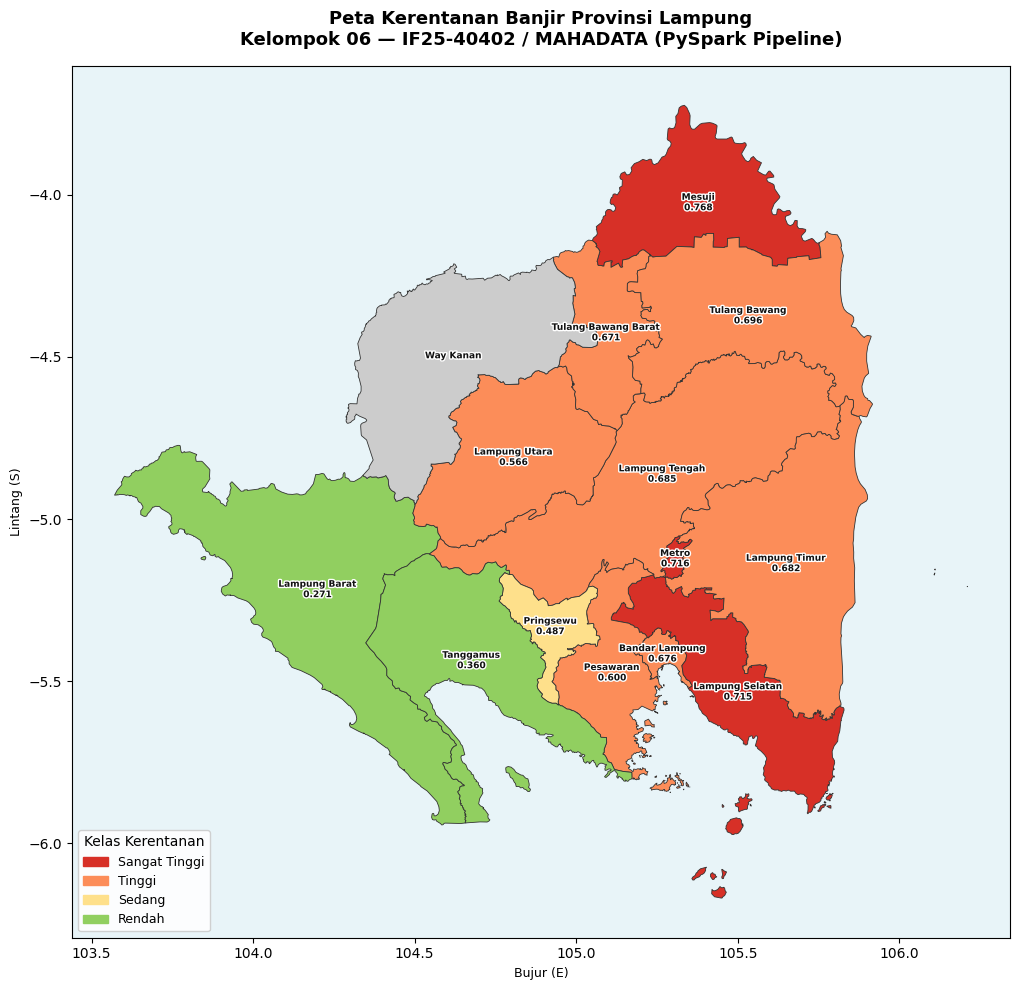

  Peta statis tersimpan: /content/peta_kerentanan_banjir_spark.png
  Peta interaktif tersimpan: /content/peta_kerentanan_banjir_spark.html
  Tabel CSV tersimpan: /content/hasil_kerentanan_spark.csv

[TASK 5] Output selesai.

Pipeline selesai — Kelompok 06 / IF25-40402 MAHADATA
DAG  : ingest >> preprocess >> merge >> scoring >> output
Tools: Apache Kafka (simulasi) + PySpark + Airflow DAG


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Task 5 — OUTPUT: Choropleth Map + Tabel + Export

!pip install geopandas folium mapclassify -q

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import folium
import os, requests

print('[TASK 5] Memulai OUTPUT — peta & tabel hasil...')

# 5.1 Konversi Spark -> Pandas
hasil = sdf_hasil.toPandas()
print(f'  Data hasil: {len(hasil)} kabupaten/kota')
print(hasil[['kabupaten', 'skor_kerentanan', 'kelas_kerentanan']].to_string(index=False))

# 5.2 Download shapefile GADM Indonesia
GADM_URL  = 'https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IDN_2.json'
GADM_PATH = '/content/gadm41_IDN_2.json' if IN_COLAB else '/tmp/gadm41_IDN_2.json'

if not os.path.exists(GADM_PATH):
    print('  Mengunduh shapefile GADM (~5 MB)...')
    r = requests.get(GADM_URL, stream=True, timeout=60)
    with open(GADM_PATH, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    print('  Download selesai.')

gdf_all = gpd.read_file(GADM_PATH)
gdf     = gdf_all[gdf_all['NAME_1'] == 'Lampung'].copy()
print(f'  Kabupaten/kota Lampung di GADM: {len(gdf)}')

# 5.3 Mapping nama GADM -> nama model
GADM_MAP = {
    'BandarLampung'    : 'Bandar Lampung',
    'LampungBarat'     : 'Lampung Barat',
    'LampungSelatan'   : 'Lampung Selatan',
    'LampungTengah'    : 'Lampung Tengah',
    'LampungTimur'     : 'Lampung Timur',
    'LampungUtara'     : 'Lampung Utara',
    'Mesuji'           : 'Mesuji',
    'Metro'            : 'Metro',
    'Pesawaran'        : 'Pesawaran',
    'Pesisir Barat'    : 'Pesisir Barat',
    'PesisirBarat'     : 'Pesisir Barat',
    'Pringsewu'        : 'Pringsewu',
    'Tanggamus'        : 'Tanggamus',
    'TulangBawangBarat': 'Tulang Bawang Barat',
    'Tulangbawang'     : 'Tulang Bawang',
    'WayKanan'         : 'Way Kanan',
}

gdf['kabupaten'] = gdf['NAME_2'].map(GADM_MAP)
n_unmapped = gdf['kabupaten'].isna().sum()
if n_unmapped > 0:
    print(f'  [WARN] {n_unmapped} kabupaten tidak cocok: '
          f'{gdf.loc[gdf["kabupaten"].isna(), "NAME_2"].tolist()}')

gdf = gdf.merge(hasil[['kabupaten', 'skor_kerentanan', 'kelas_kerentanan']],
                on='kabupaten', how='left')
print(f'  Kabupaten cocok dengan model: {gdf["skor_kerentanan"].notna().sum()} dari {len(gdf)}')

# 5.4 Peta Statis (Matplotlib)
WARNA_KELAS = {
    'Sangat Tinggi' : '#d73027',
    'Tinggi'        : '#fc8d59',
    'Sedang'        : '#fee08b',
    'Rendah'        : '#91cf60',
    'Sangat Rendah' : '#1a9850',
    'Tidak Ada Data': '#cccccc',
}

gdf['warna'] = gdf['kelas_kerentanan'].map(WARNA_KELAS).fillna('#cccccc')
gdf_plot     = gdf.to_crs(epsg=4326)

fig, ax = plt.subplots(1, 1, figsize=(14, 10))
gdf_plot.plot(ax=ax, color=gdf_plot['warna'], edgecolor='#333333', linewidth=0.6)

for _, row in gdf_plot.iterrows():
    if row.geometry is None:
        continue
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    nama = row['kabupaten'] if pd.notna(row['kabupaten']) else row['NAME_2']
    skor = f'{row["skor_kerentanan"]:.3f}' if pd.notna(row.get('skor_kerentanan')) else ''
    ax.annotate(f'{nama}\n{skor}', xy=(cx, cy), ha='center', va='center',
                fontsize=6.5, fontweight='bold', color='#111111',
                path_effects=[pe.withStroke(linewidth=2, foreground='white')])

urutan_kelas = ['Sangat Tinggi', 'Tinggi', 'Sedang', 'Rendah', 'Sangat Rendah']
kelas_muncul = [k for k in urutan_kelas if k in gdf['kelas_kerentanan'].values]
patches = [mpatches.Patch(color=WARNA_KELAS[k], label=k) for k in kelas_muncul]
ax.legend(handles=patches, title='Kelas Kerentanan',
          loc='lower left', fontsize=9, title_fontsize=10, framealpha=0.9)

ax.set_title(
    'Peta Kerentanan Banjir Provinsi Lampung\n'
    'Kelompok 06 — IF25-40402 / MAHADATA (PySpark Pipeline)',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('Bujur (E)', fontsize=9)
ax.set_ylabel('Lintang (S)', fontsize=9)
ax.set_facecolor('#e8f4f8')
fig.patch.set_facecolor('white')
plt.tight_layout()

PATH_PNG = '/content/peta_kerentanan_banjir_spark.png' if IN_COLAB else '/tmp/peta_kerentanan_banjir_spark.png'
plt.savefig(PATH_PNG, dpi=200, bbox_inches='tight')
plt.show()
print(f'  Peta statis tersimpan: {PATH_PNG}')

# 5.5 Peta Interaktif (Folium)
gdf_folium = gdf_plot.copy()
gdf_folium['skor_str']  = gdf_folium['skor_kerentanan'].apply(
    lambda x: f'{x:.3f}' if pd.notna(x) else 'N/A')
gdf_folium['kelas_str'] = gdf_folium['kelas_kerentanan'].fillna('Tidak Ada Data')
df_skor = gdf_folium[['kabupaten', 'skor_kerentanan']].dropna()

m = folium.Map(location=[-4.5, 105.2], zoom_start=8, tiles='CartoDB positron')
folium.Choropleth(
    geo_data=gdf_folium.__geo_interface__,
    data=df_skor,
    columns=['kabupaten', 'skor_kerentanan'],
    key_on='feature.properties.kabupaten',
    fill_color='RdYlGn_r',
    fill_opacity=0.75,
    line_opacity=0.5,
    legend_name='Skor Kerentanan Banjir (0-1)',
    nan_fill_color='#cccccc',
).add_to(m)
folium.GeoJson(
    gdf_folium.__geo_interface__,
    style_function=lambda x: {'fillOpacity': 0, 'weight': 0},
    tooltip=folium.GeoJsonTooltip(
        fields=['kabupaten', 'kelas_str', 'skor_str'],
        aliases=['Kabupaten/Kota', 'Kelas Kerentanan', 'Skor'],
    )
).add_to(m)

PATH_HTML = '/content/peta_kerentanan_banjir_spark.html' if IN_COLAB else '/tmp/peta_kerentanan_banjir_spark.html'
m.save(PATH_HTML)
print(f'  Peta interaktif tersimpan: {PATH_HTML}')

# 5.6 Export tabel CSV
PATH_CSV = '/content/hasil_kerentanan_spark.csv' if IN_COLAB else '/tmp/hasil_kerentanan_spark.csv'
hasil.to_csv(PATH_CSV, index=False)
print(f'  Tabel CSV tersimpan: {PATH_CSV}')

print('\n[TASK 5] Output selesai.')
print()
print('Pipeline selesai — Kelompok 06 / IF25-40402 MAHADATA')
print('DAG  : ingest >> preprocess >> merge >> scoring >> output')
print('Tools: Apache Kafka (simulasi) + PySpark + Airflow DAG')

if IN_COLAB:
    from google.colab import files
    files.download(PATH_PNG)
    files.download(PATH_HTML)
    files.download(PATH_CSV)


def run_output():
    """Entry point untuk Airflow PythonOperator — task_output."""
    print('[Airflow] task_output dijalankan')


## Ringkasan Pipeline

| Task | Tool Big Data | Input | Output |
|------|--------------|-------|--------|
| `task_ingest` | Apache Kafka (simulasi) | CSV, XLSX, stream simulasi | 4 Kafka topics |
| `task_preprocess` | PySpark DataFrame + MLlib | Kafka messages | 4 Spark DataFrames bersih |
| `task_merge` | PySpark Join (inner + left) | 4 Spark DFs | 1 DataFrame terintegrasi |
| `task_scoring` | PySpark MLlib MinMaxScaler + Pipeline | DataFrame terintegrasi | Skor & kelas kerentanan |
| `task_output` | GeoPandas + Folium | Skor kerentanan | Peta statis + interaktif + CSV |

### Mengapa PySpark?
- **Volume**: data spasial GEE (ratusan GB citra raster) diproses secara terdistribusi
- **Velocity**: stream curah hujan harian dari Kafka dikonsumsi & diproses paralel
- **Variety**: data heterogen (raster GeoTIFF, CSV, XLSX, JSON) difusikan dalam satu pipeline

### Mengapa Airflow?
- Pipeline berbentuk **DAG** secara alami: ingest -> preprocess -> merge -> scoring -> output
- Bisa dijadwalkan **`@weekly`** untuk tarik data baru dari GEE/BMKG/BPS otomatis
- Mudah di-monitor, retry otomatis jika satu task gagal
